STEP 4: Quantum Teleportation Result



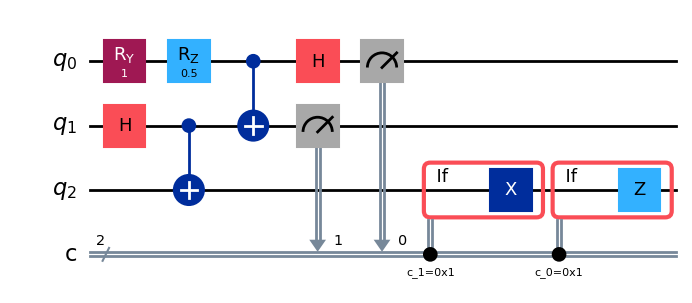

/tmp/ipython-input-2645619756.py:67: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instruction, qargs, cargs in qc_with_measurements.data:


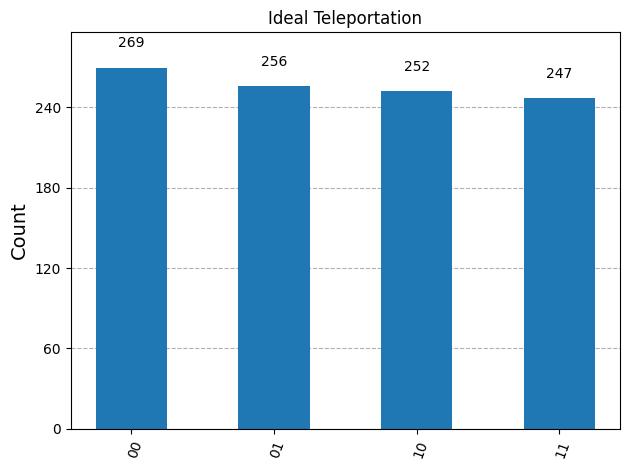

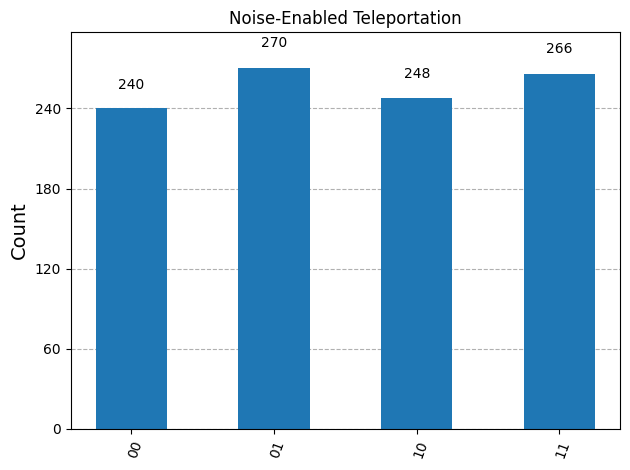

Teleportation Fidelity: 0.5000


In [2]:
!pip install qiskit ipywidgets matplotlib pylatexenc --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import ipywidgets as widgets
from IPython.display import display, clear_output
import pylatexenc # Explicitly import pylatexenc

# --------------------------------------------------
# Step 1: Noise Model
# --------------------------------------------------
def create_noise_model(p):
    noise = NoiseModel()
    error = depolarizing_error(p, 1)
    noise.add_all_qubit_quantum_error(error, ['h', 'x', 'z', 'cx'])
    return noise

# --------------------------------------------------
# Step 2: Teleportation Circuit
# --------------------------------------------------
def build_teleportation(theta, phi):
    qc = QuantumCircuit(3, 2)

    # Prepare arbitrary input state |ψ⟩
    qc.ry(theta, 0)
    qc.rz(phi, 0)

    # Create Bell pair
    qc.h(1)
    qc.cx(1, 2)

    # Bell measurement
    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    # Conditional corrections using if_test
    # Apply X to qubit 2 if classical bit 1 is 1
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(2)
    # Apply Z to qubit 2 if classical bit 0 is 1
    with qc.if_test((qc.clbits[0], 1)):
        qc.z(2)

    return qc

# --------------------------------------------------
# Step 3: Simulation Engine
# --------------------------------------------------
def run_teleportation(theta, phi, noise_strength, draw_method):
    clear_output(wait=True)

    print("STEP 4: Quantum Teleportation Result\n")

    qc_with_measurements = build_teleportation(theta, phi)
    display(qc_with_measurements.draw(draw_method))

    # Create a copy of the circuit *without* measurements and *without* control flow
    # for statevector calculation. Note: This means the conditional corrections
    # are not applied in this specific statevector calculation.
    qc_for_statevector = QuantumCircuit(qc_with_measurements.num_qubits, qc_with_measurements.num_clbits)
    for instruction, qargs, cargs in qc_with_measurements.data:
        # Exclude 'measure' and 'if_else' instructions (control flow)
        if instruction.name not in ['measure', 'if_else']:
            qc_for_statevector.append(instruction, qargs, cargs)

    # Initial ideal state
    ideal_state = QuantumCircuit(1)
    ideal_state.ry(theta, 0)
    ideal_state.rz(phi, 0)
    psi = Statevector.from_instruction(ideal_state)

    # Simulators
    ideal_sim = AerSimulator()
    noisy_sim = AerSimulator(noise_model=create_noise_model(noise_strength))

    result_ideal = ideal_sim.run(qc_with_measurements, shots=1024).result()
    result_noisy = noisy_sim.run(qc_with_measurements, shots=1024).result()

    counts_ideal = result_ideal.get_counts()
    counts_noisy = result_noisy.get_counts()

    display(plot_histogram(counts_ideal, title="Ideal Teleportation"))
    display(plot_histogram(counts_noisy, title="Noise-Enabled Teleportation"))

    # Get the statevector of the final qubit (qubit 2) by tracing out qubits 0 and 1
    # The qc_for_statevector only contains the operations up to the Bell measurement part
    # without the classical corrections, as Statevector.from_instruction cannot handle 'if_else'.
    # This fidelity will reflect the entanglement quality before final corrections.
    final_state_all_qubits = Statevector.from_instruction(qc_for_statevector)
    # Extract the state of the teleported qubit (qubit 2)
    final_state = partial_trace(final_state_all_qubits, [0, 1])

    fidelity = state_fidelity(psi, final_state)

    print(f"Teleportation Fidelity: {fidelity:.4f}")

# --------------------------------------------------
# Step 4: UI / UX Controls
# --------------------------------------------------
theta_slider = widgets.FloatSlider(
    value=1.0, min=0, max=np.pi, step=0.1,
    description="θ (State)"
)

phi_slider = widgets.FloatSlider(
    value=0.5, min=0, max=2*np.pi, step=0.1,
    description="φ (Phase)"
)

noise_slider = widgets.FloatSlider(
    value=0.0, min=0, max=0.2, step=0.01,
    description="Noise"
)

draw_method_selector = widgets.Dropdown(
    options=[('Text (ASCII)', 'text'), ('Matplotlib', 'mpl')],
    value='mpl',
    description='Circuit Draw Method:'
)

run_button = widgets.Button(
    description="Run Quantum Teleportation",
    button_style="success"
)

def on_run_clicked(b):
    run_teleportation(theta_slider.value, phi_slider.value, noise_slider.value, draw_method_selector.value)

run_button.on_click(on_run_clicked)

# --------------------------------------------------
# UX Layout
# --------------------------------------------------
display(
    widgets.VBox([
        widgets.HTML("<h2>Quantum Teleportation Simulator</h2>"),
        widgets.HTML("<b>Step 1:</b> Configure quantum state"),
        theta_slider,
        phi_slider,
        widgets.HTML("<b>Step 2:</b> Add noise (optional)"),
        noise_slider,
        widgets.HTML("<b>Step 3:</b> Execute teleportation"),
        draw_method_selector,
        run_button
    ])
)
